<a href="https://colab.research.google.com/github/saurabhsg444/Amazon-Prime-Video-EDA/blob/main/Module_2_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [67]:
credits_df = pd.read_csv('/content/drive/MyDrive/Module 2/credits.csv')
titles_df = pd.read_csv('/content/drive/MyDrive/Module 2/titles.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
print("Data loaded successfully.")
print(f"Titles shape: {titles_df.shape}")
print(f"Credits shape: {credits_df.shape}")

Data loaded successfully.
Titles shape: (9871, 15)
Credits shape: (124235, 5)


In [69]:
titles_df['genres'] = titles_df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
titles_df['production_countries'] = titles_df['production_countries'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

In [70]:
genres_exploded = titles_df.explode('genres')
genre_counts = genres_exploded['genres'].value_counts().head(10)

In [71]:
countries_exploded = titles_df.explode('production_countries')
country_counts = countries_exploded['production_countries'].value_counts().head(10)

In [72]:
min_votes = titles_df['imdb_votes'].quantile(0.9) # Filter for top 10% vote count to ensure significance
top_rated = titles_df[titles_df['imdb_votes'] >= min_votes].sort_values('imdb_score', ascending=False).head(10)

In [73]:
actors_df = credits_df[credits_df['role'] == 'ACTOR']
top_actors = actors_df['name'].value_counts().head(10)

In [74]:
actors_df = credits_df[credits_df['role'] == 'ACTOR']
top_actors = actors_df['name'].value_counts().head(10)
display(top_actors)

,count
name,
George 'Gabby' Hayes,49
Roy Rogers,45
Bess Flowers,44
Gene Autry,40
Nassar,37
Charles King,36
Herman Hack,35
George Morrell,34
Forrest Taylor,34


Text(0.5, 1.0, 'Movies vs TV Shows Ratio')

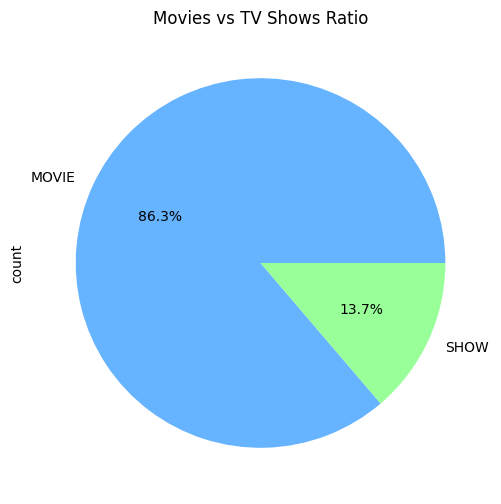

In [34]:
# 1. Content Type Distribution (Pie Chart)
plt.figure(figsize=(6,6))
titles_df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title("Movies vs TV Shows Ratio")



/tmp/ipykernel_12955/2427896116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titles_df, x='type', palette='viridis')


<Axes: xlabel='type', ylabel='count'>

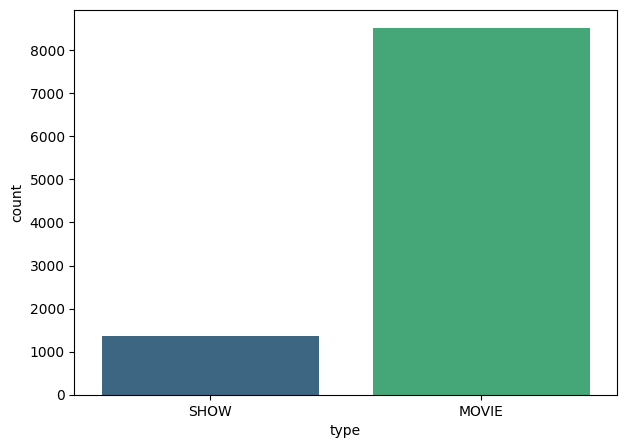

In [35]:
# 2. Content Type Distribution (Countplot)
plt.figure(figsize=(7,5))
sns.countplot(data=titles_df, x='type', palette='viridis')

<Axes: xlabel='genres'>

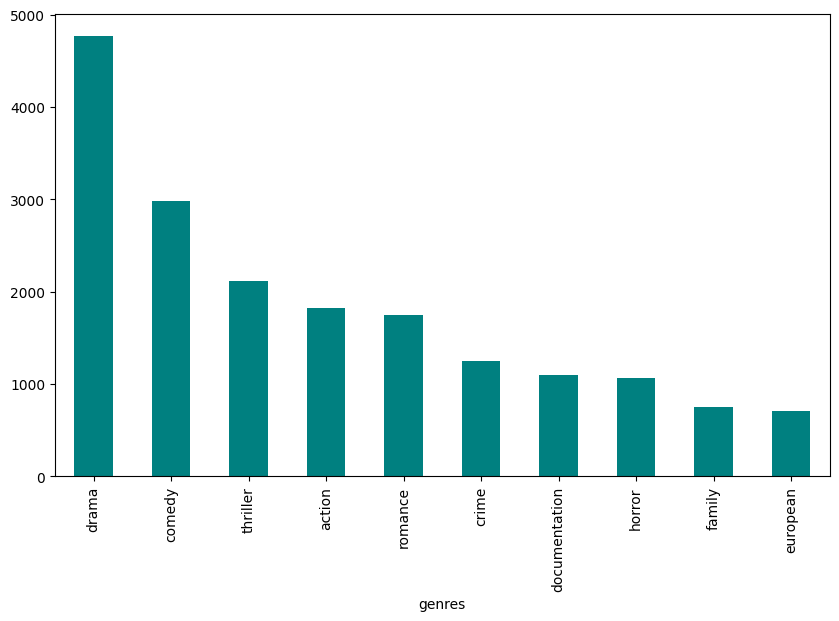

In [36]:
# 3. Top 10 Genres (Bar Chart)
plt.figure(figsize=(10,6))
titles_df.explode('genres')['genres'].value_counts().head(10).plot(kind='bar', color='teal')

<Axes: xlabel='imdb_score', ylabel='Count'>

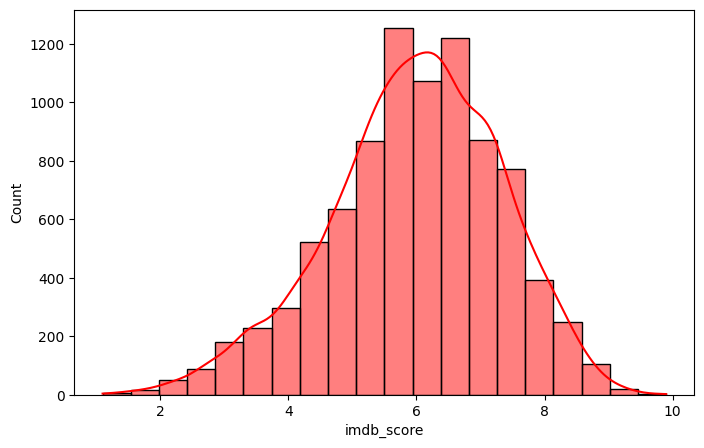

In [37]:
# 4. IMDb Score Distribution (Histogram)
plt.figure(figsize=(8,5))
sns.histplot(titles_df['imdb_score'], bins=20, kde=True, color='red')

<Axes: xlabel='release_year'>

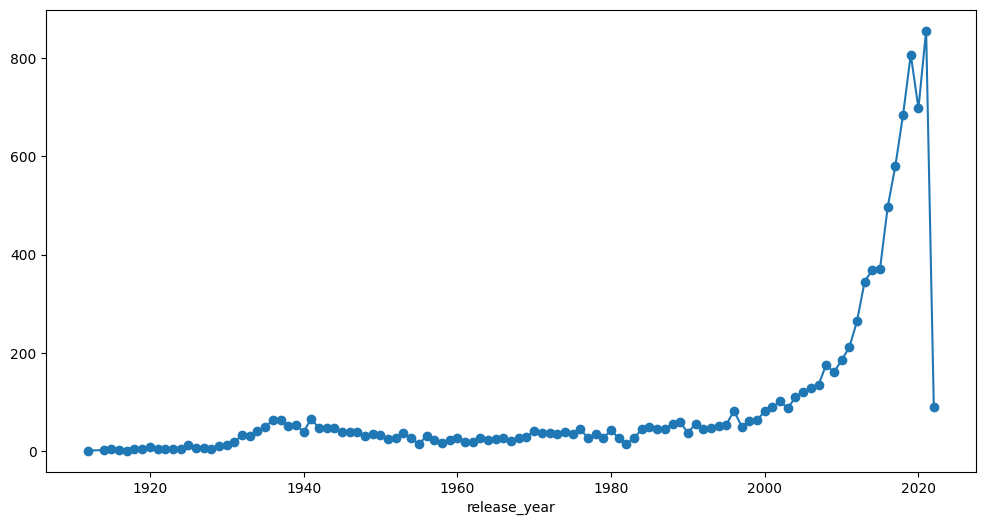

In [38]:
# 5. Release Year Trend (Line Plot)
plt.figure(figsize=(12,6))
titles_df['release_year'].value_counts().sort_index().plot(kind='line', marker='o')


<Axes: xlabel='imdb_score', ylabel='tmdb_score'>

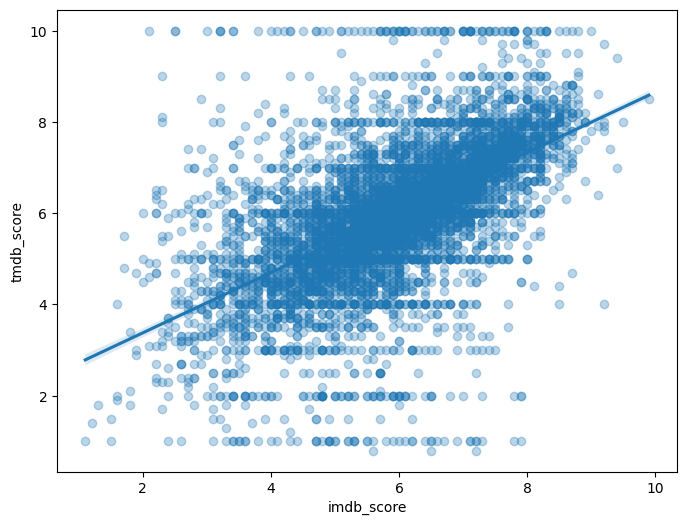

In [39]:
# 6. IMDb Score vs TMDB Score (Regression Plot)
plt.figure(figsize=(8,6))
sns.regplot(data=titles_df, x='imdb_score', y='tmdb_score', scatter_kws={'alpha':0.3})

<Axes: ylabel='production_countries'>

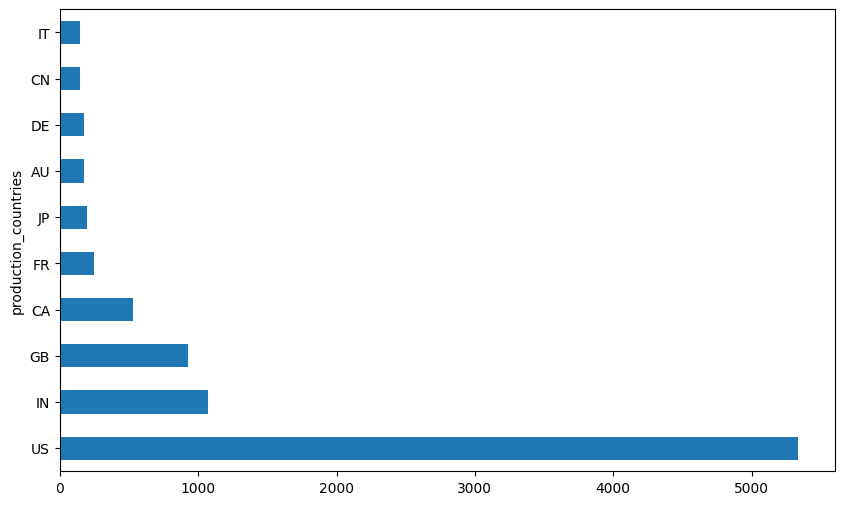

In [44]:
# 7. Top 10 Production Countries (Horizontal Bar)
plt.figure(figsize=(10,6))
titles_df.explode('production_countries')['production_countries'].value_counts().head(10).plot(kind='barh')

<Axes: xlabel='runtime', ylabel='Density'>

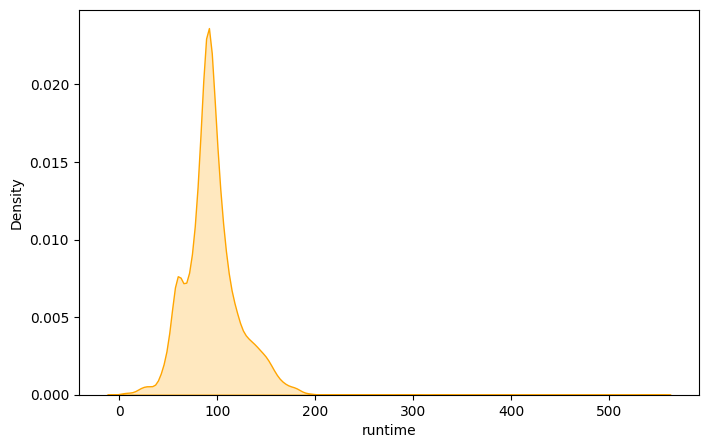

In [41]:
# 8. Runtime Distribution for Movies
plt.figure(figsize=(8,5))
sns.kdeplot(titles_df[titles_df['type']=='MOVIE']['runtime'], fill=True, color="orange")

<Axes: >

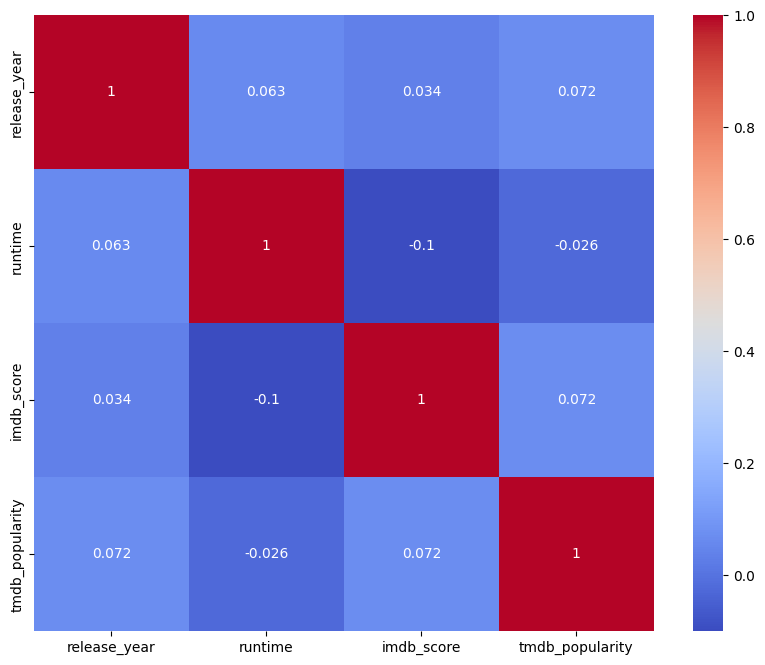

In [42]:
# 9. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(titles_df[['release_year', 'runtime', 'imdb_score', 'tmdb_popularity']].corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='age_certification', ylabel='count'>

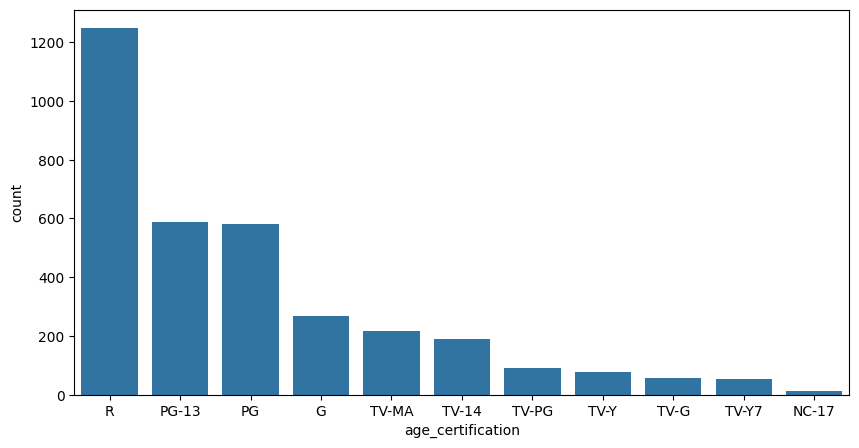

In [45]:
# 10. Age Certification Distribution
plt.figure(figsize=(10,5))
sns.countplot(data=titles_df, x='age_certification', order=titles_df['age_certification'].value_counts().index)

<Axes: xlabel='type', ylabel='imdb_score'>

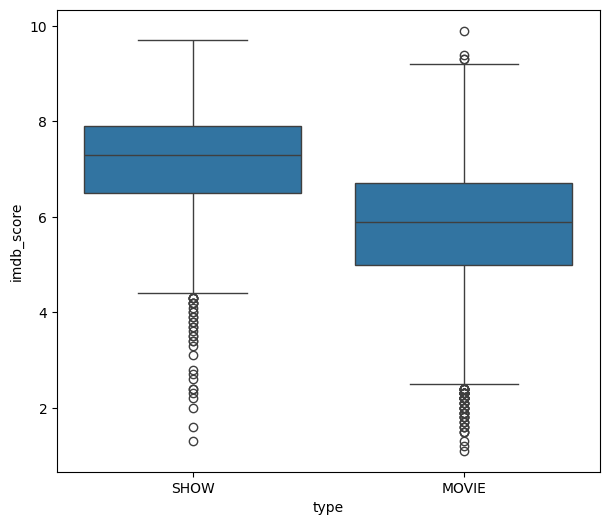

In [47]:
# 11. Boxplot: IMDb Score by Content Type
plt.figure(figsize=(7,6))
sns.boxplot(data=titles_df, x='type', y='imdb_score')

<Axes: xlabel='imdb_score', ylabel='title'>

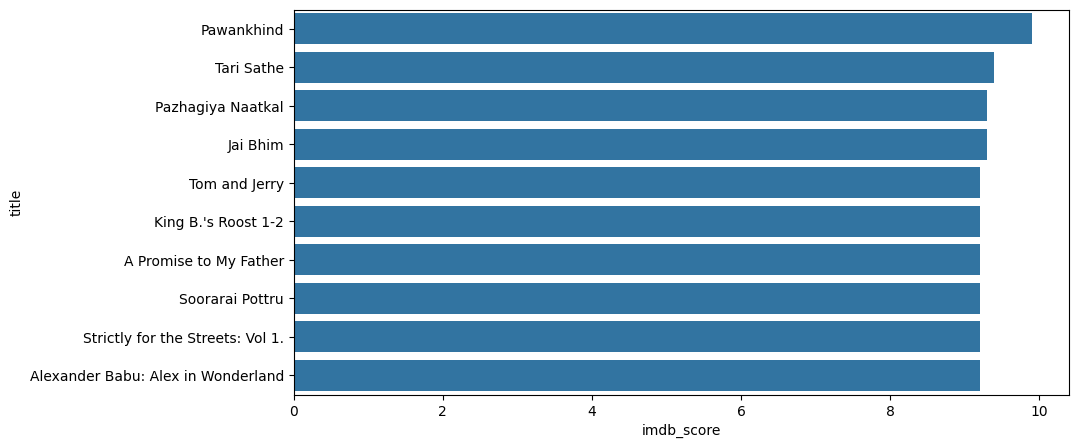

In [48]:
# 12. Top 10 Highly Rated Movies (IMDb > 8.0 & high votes)
top_movies = titles_df[titles_df['type']=='MOVIE'].sort_values(by='imdb_score', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(data=top_movies, x='imdb_score', y='title')

<Axes: xlabel='release_year'>

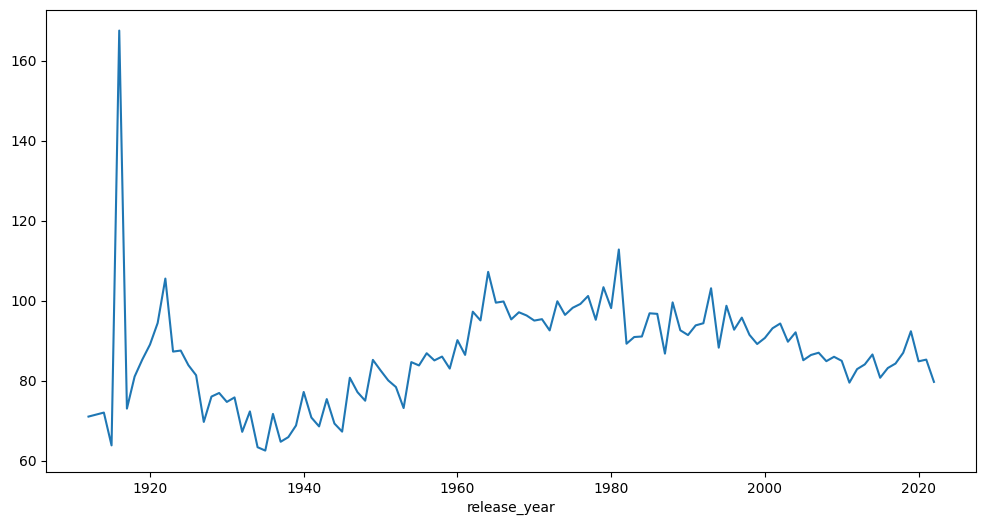

In [49]:
# 13. Average Runtime over the Years
plt.figure(figsize=(12,6))
titles_df.groupby('release_year')['runtime'].mean().plot()

<Axes: xlabel='release_year', ylabel='tmdb_popularity'>

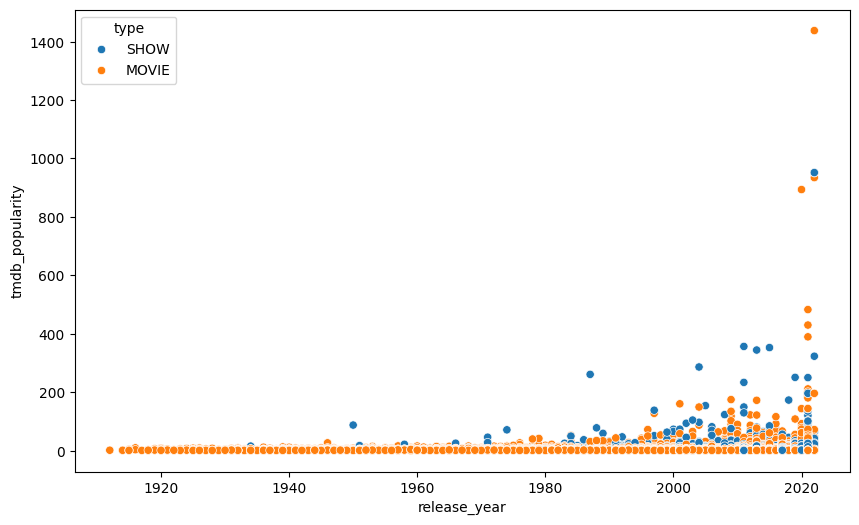

In [50]:
# 14. TMDB Popularity vs Release Year
plt.figure(figsize=(10,6))
sns.scatterplot(data=titles_df, x='release_year', y='tmdb_popularity', hue='type')

<Axes: xlabel='seasons', ylabel='Count'>

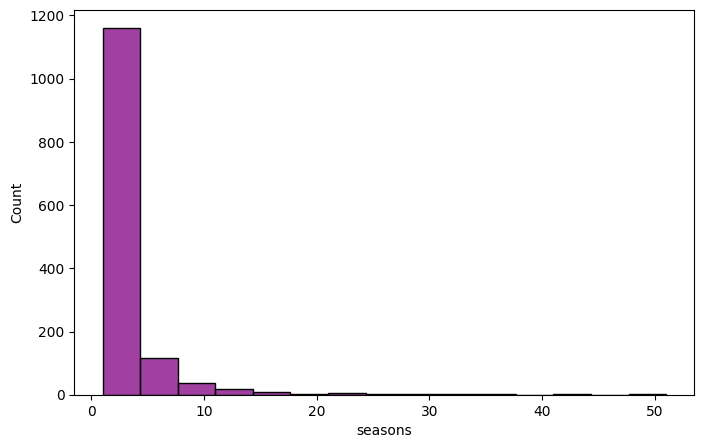

In [51]:
# 15. Number of Seasons for TV Shows
plt.figure(figsize=(8,5))
sns.histplot(titles_df[titles_df['type']=='SHOW']['seasons'], bins=15, color='purple')

<Axes: xlabel='name'>

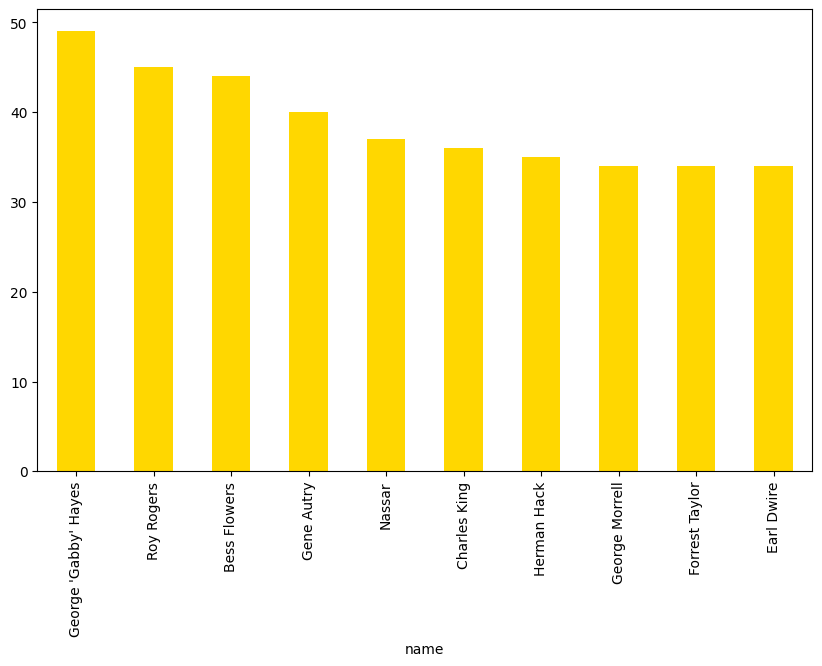

In [65]:
# 17. Top 10 Actors by Appearance
plt.figure(figsize=(10,6))
credits_df[credits_df['role']=='ACTOR']['name'].value_counts().head(10).plot(kind='bar', color='gold')

<Axes: ylabel='count'>

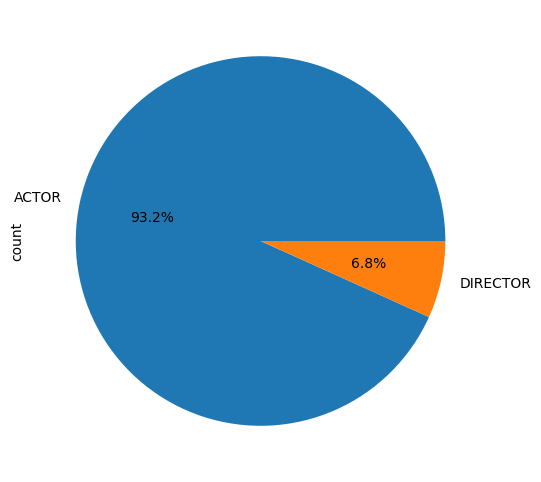

In [59]:
# 18. Proportion of Roles (Actor vs Director)
plt.figure(figsize=(6,6))
credits_df['role'].value_counts().plot.pie(autopct='%1.1f%%')

<Axes: >

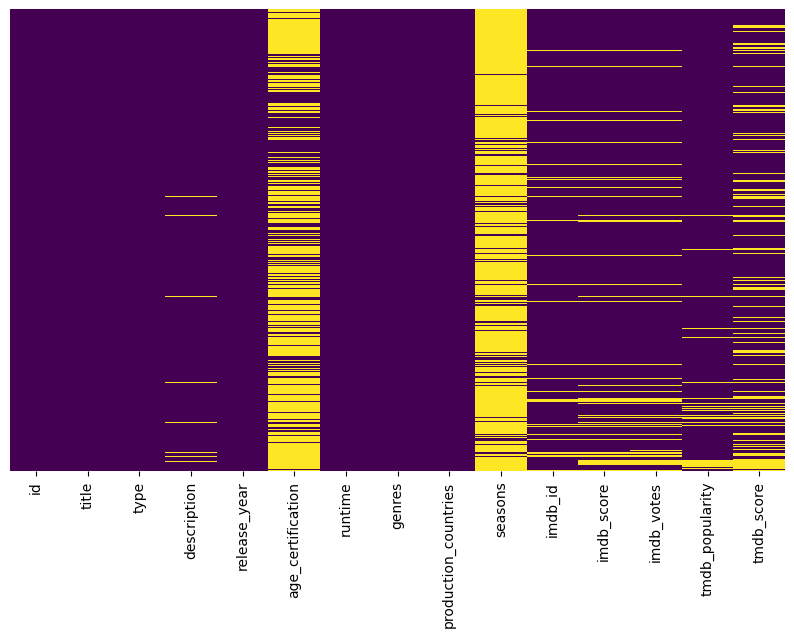

In [60]:
# 19. Missing Data Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(titles_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

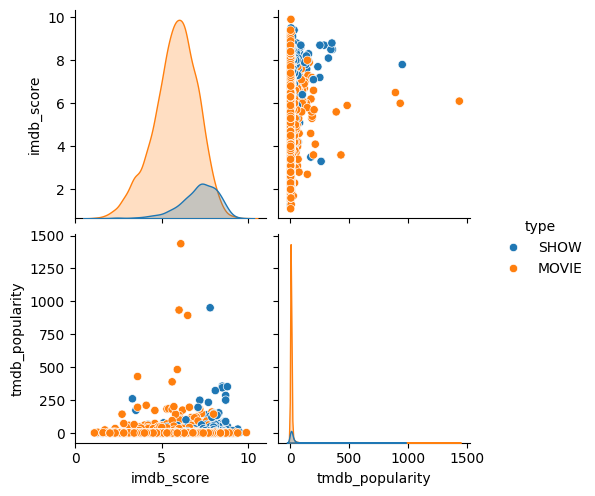

In [61]:
# 20. Pairplot (Sampling for speed)
sns.pairplot(titles_df[['imdb_score', 'tmdb_popularity', 'type']].dropna(), hue='type')

plt.show()